In [2]:
import numpy as np

In [7]:
int_id_data = np.load(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\int_id_data.npy", allow_pickle=True)
attack_onehot = np.load(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\attack_onehot.npy", allow_pickle=True)
attack_labels = np.load(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\attack_labels.npy", allow_pickle=True)


int_id_data_test = np.load(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\int_id_data_test.npy", allow_pickle=True)
attack_onehot_test = np.load(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\attack_onehot_test.npy", allow_pickle=True)
attack_labels_test = np.load(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\attack_labels_test.npy", allow_pickle=True)

In [9]:
import numpy as np

def sliding_windows_id_data(samples, labels, window_size=32, step=2, attack_label='T'):
    n = len(samples)

    windows = []
    window_labels = []
    next_id_datas = []

    for start in range(0, n - window_size, step):
        end = start + window_size

        windows.append(samples[start:end])
        next_id_datas.append(samples[end])
        window_labels.append(
            attack_label if attack_label in labels[start:end] else 'R'
        )

    return (
        np.array(windows, dtype=object),
        np.array(next_id_datas, dtype=object),
        np.array(window_labels, dtype=object)
    )

In [12]:
windows, next, windowed_labels = sliding_windows_id_data(int_id_data, attack_labels)

In [19]:
import tensorflow as tf
import tensorflow as tf

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 10, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(4, activation='softmax'))

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(int_windowed_id_data, window_attack_onehot, epochs=5, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 196s 69ms/step - accuracy: 0.9944 - loss: 0.0557 - val_accuracy: 0.9993 - val_loss: 0.0042
Epoch 2/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 202s 69ms/step - accuracy: 0.9992 - loss: 0.0045 - val_accuracy: 0.9996 - val_loss: 0.0023
Epoch 3/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 194s 69ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9996 - val_loss: 0.0022
Epoch 4/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 196s 70ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9996 - val_loss: 0.0019
Epoch 5/5
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 196s 70ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.9997 - val_loss: 0.0013


In [21]:
loss, accuracy = model.evaluate(int_windowed_id_data_test, window_attack_onehot_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0028
Test accuracy: 0.9995


In [22]:
label_map = np.array(['R', 'D', 'F', 'S'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(int_windowed_id_data_test))
print(recovered_labels[:20])

54870/54870 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


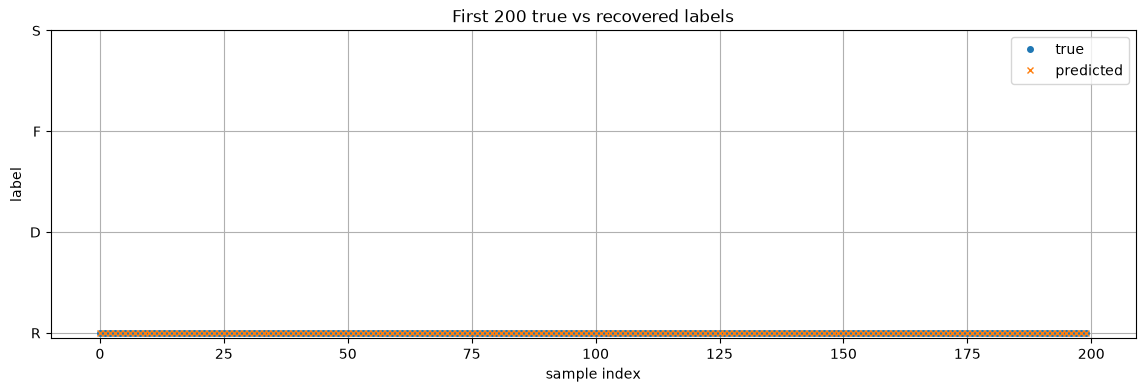

In [23]:
true_labels = onehot_to_labels(window_attack_onehot_test)
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

y_pred_probs = model.predict(int_windowed_id_data_test)
y_pred = onehot_to_labels(y_pred_probs)
y_true = onehot_to_labels(window_attack_onehot_test)

report = classification_report(
    y_true,
    y_pred,
    labels=label_map,
    target_names=label_map,
    zero_division=0,
)

cm = confusion_matrix(y_true, y_pred, labels=label_map)

tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(fps, fps + tns, out=np.zeros_like(fps, dtype=float), where=(fps + tns) != 0)
fnr = np.divide(fns, fns + tps, out=np.zeros_like(fns, dtype=float), where=(fns + tps) != 0)

print("Classification report:")
print(report)
print("Confusion matrix:")
print(cm)

precision = precision_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)

for label, p, r, f, fp_rate, fn_rate in zip(label_map, precision, recall, f1, fpr, fnr):
    print(
        f"{label}: precision={p:.4f}, recall={r:.4f}, "
        f"f1={f:.4f}, false positive rate={fp_rate:.4f}, false negative rate={fn_rate:.4f}"
    )

54870/54870 ━━━━━━━━━━━━━━━━━━━━ 75s 1ms/step
Classification report:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00    927766
           D       1.00      1.00      1.00    147189
           F       1.00      1.00      1.00    187449
           S       1.00      1.00      1.00    493415

    accuracy                           1.00   1755819
   macro avg       1.00      1.00      1.00   1755819
weighted avg       1.00      1.00      1.00   1755819

Confusion matrix:
[[927647     38     24     57]
 [   189 146998      1      1]
 [   274      3 187172      0]
 [   295      0      0 493120]]
R: precision=0.9992, recall=0.9999, f1=0.9995, false positive rate=0.0009, false negative rate=0.0001
D: precision=0.9997, recall=0.9987, f1=0.9992, false positive rate=0.0000, false negative rate=0.0013
F: precision=0.9999, recall=0.9985, f1=0.9992, false positive rate=0.0000, false negative rate=0.0015
S: precision=0.9999, recall=0.9994, f1=0.9996, 

In [25]:
import os
from tensorflow import keras

os.makedirs("saved_models", exist_ok=True)
model.save(os.path.join("saved_models", "HCRL_model.h5"))
print("Saved model to saved_models/HCRL_model.h5")

Saved model to saved_models/HCRL_model.h5


In [33]:
import numpy as np

int_windowed_id_data = np.expand_dims(int_windowed_id_data, axis=-1)
int_windowed_id_data_test = np.expand_dims(int_windowed_id_data_test, axis=-1)

def representative_dataset():
    for i in range(100):
        yield [int_windowed_id_data[i:i+1].astype(np.float32)]

In [34]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("cnn_int8.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\nb0801\AppData\Local\Temp\tmp6x2dcp_i\assets


INFO:tensorflow:Assets written to: C:\Users\nb0801\AppData\Local\Temp\tmp6x2dcp_i\assets


Saved artifact at 'C:\Users\nb0801\AppData\Local\Temp\tmp6x2dcp_i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 10, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1876386257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876386258896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876386258128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876386257168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876386260816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876386261584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876386261200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876386260624: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [35]:
interpreter = tf.lite.Interpreter(
    model_path="cnn_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [36]:
sample = int_windowed_id_data[0:1].astype(np.float32)

scale, zero_point = input_details[0]["quantization"]

sample_int8 = (sample / scale + zero_point).astype(np.int8)

In [ ]:
import tensorflow as tf
import numpy as np
import time

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

# ----------------------------
# Load TFLite model
# ----------------------------

interpreter = tf.lite.Interpreter(model_path="cnn_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero = input_details[0]["quantization"]
output_scale, output_zero = output_details[0]["quantization"]

# ----------------------------
# Run inference
# ----------------------------

predictions = []

start = time.perf_counter()

for sample in int_windowed_id_data_test:

    sample = np.expand_dims(sample, axis=0).astype(np.float32)

    # Quantize input if needed
    if input_details[0]["dtype"] == np.int8:
        sample = (sample / input_scale + input_zero).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], sample)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])

    # Dequantize output
    if output_details[0]["dtype"] == np.int8:
        output = (output.astype(np.float32) - output_zero) * output_scale

    predictions.append(np.argmax(output))

end = time.perf_counter()

print(f"Average inference time: {(end-start)/len(int_windowed_id_data_test)*1000:.3f} ms")

predictions = np.array(predictions)

# ----------------------------
# Convert one-hot labels
# ----------------------------

y_true = np.argmax(window_attack_onehot_test, axis=1)

# ----------------------------
# Accuracy
# ----------------------------

accuracy = accuracy_score(y_true, predictions)

print(f"\nTest accuracy: {accuracy:.4f}")

# ----------------------------
# Classification report
# ----------------------------

target_names = ["R","D","F","S"]

print("\nClassification report:")
print(
    classification_report(
        y_true,
        predictions,
        target_names=target_names,
        digits=4
    )
)

# ----------------------------
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(y_true, predictions)

print("\nConfusion matrix:")
print("\tR\tD\tF\tS")
print(cm)

# ----------------------------
# Per-class metrics
# ----------------------------

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    predictions
)

for i, cls in enumerate(target_names):

    FP = cm[:, i].sum() - cm[i, i]
    FN = cm[i, :].sum() - cm[i, i]
    TP = cm[i, i]
    TN = cm.sum() - (TP + FP + FN)

    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)

    print(
        f"{cls}: "
        f"precision={precision[i]:.4f}, "
        f"recall={recall[i]:.4f}, "
        f"f1={f1[i]:.4f}, "
        f"false positive rate={fpr:.4f}, "
        f"false negative rate={fnr:.4f}"
    )

ValueError: Could not open 'cnn_int8.tflite'.

In [7]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\CNN\saved_models\cnn_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model loaded successfully")
print(f"Input shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")

Model loaded successfully
Input shape: [ 1 32 10  1]
Output shape: [1 4]


NameError: name 'int_windowed_id_data_test' is not defined